In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import os
while not os.path.isdir('.git'):
    os.chdir('../..')

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

fig_width = 8.4

mpl.rcParams["axes.labelsize"] = 9
mpl.rcParams["xtick.labelsize"] = 9
mpl.rcParams["ytick.labelsize"] = 9
mpl.rcParams["legend.fontsize"] = 9
mpl.rcParams["axes.titlesize"] = 9

# Figure Results 5

## Example spikes in each synapse

In [67]:
def read_spike_times(idx, carrier = 1000, offset = 5, strength = 0.9, initial_weight = 0.1):
    if carrier is None:
        filename = f"noTI_{initial_weight}"
    else:
        filename = f"{carrier}_{offset}_{strength}_{initial_weight}"

    spike_times = pd.read_csv(
        f"output/temporal-interference-1/{idx}/subthreshold_conductance/theta_poisson/{filename}/synapse_stimuli.csv",
        header = None
    )
    spike_times = spike_times.fillna('').values.tolist()
    spike_times = [[x for x in row if x != ""] for row in spike_times]

    return spike_times

In [68]:
idx = 0
initial_weight = 0.1

spike_times = read_spike_times(
    idx = idx,
    initial_weight = initial_weight,
    carrier = None
)

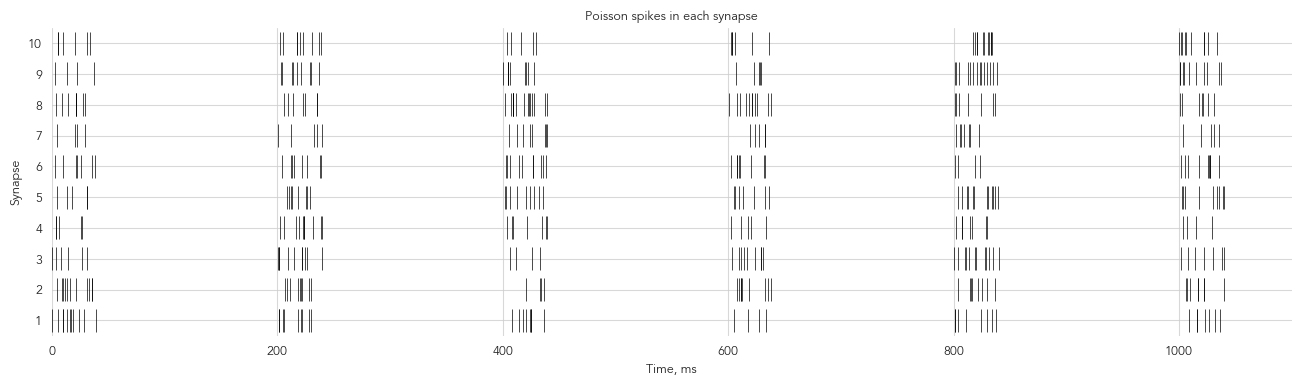

In [69]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (16, 4))
ax = axs

for i, spikes in enumerate(spike_times):
    ax.eventplot(spikes, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

ax.set_ylim(0.5, 10.5)
ax.set_ylabel("Synapse")
ax.set_yticks(np.arange(1, 11, 1))

ax.set_xlabel("Time, ms")
ax.set_xticks(np.arange(0, 1100, 200))
ax.set_xlim(0, 1_100)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("Poisson spikes in each synapse")
ax.grid(alpha = 0.75)
plt.show()

In [70]:
def isi_from_times(spike_times):
    return np.concatenate([ np.diff(spikes) for spikes in spike_times ])

In [71]:
def read_all_isi(carrier = 1000):
    idxs = np.arange(0, 5)

    isi = []

    for idx in idxs:
        spike_times = read_spike_times(idx = idx, initial_weight = initial_weight, carrier = None)
        isi.append(isi_from_times(spike_times))

        spike_times = read_spike_times(idx = idx, initial_weight = initial_weight, carrier = carrier, offset = 5, strength = 0.9)
        isi.append(isi_from_times(spike_times))

        spike_times = read_spike_times(idx = idx, initial_weight = initial_weight, carrier = carrier, offset = 130, strength = 0.9)
        isi.append(isi_from_times(spike_times))

        spike_times = read_spike_times(idx = idx, initial_weight = initial_weight, carrier = carrier, offset = 0, strength = 0.32)
        isi.append(isi_from_times(spike_times))

    isi = np.concatenate(isi)

    return isi

In [72]:
isi = read_all_isi()

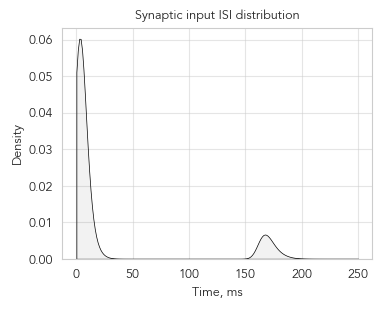

In [73]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (4, 3))
ax = axs

sns.kdeplot(
    isi,
    bw_adjust = 1,
    ax = ax,
    clip = (0, 250),
    fill = True,
    alpha = 0.05,
    color = "black",
    linewidth = 0.5
)

ax.set_xlabel("Time, ms")
ax.set_title("Synaptic input ISI distribution")
ax.grid(alpha = 0.5)
plt.show()

## Average synaptic weights

In [74]:
idxs = np.arange(0, 5)

In [75]:
def expand_time(original, max_time = 30_000):
    original["Time"] = (original["Time"] / 0.025).round() * 0.025
    original = original.sort_values("Time")

    new_time = np.arange(0, max_time + 0.025, 0.025)

    expanded = pd.DataFrame({ "Time": new_time })
    expanded = pd.merge_asof(expanded, original, on = "Time", direction = "backward")

    return expanded

In [82]:
def read_weights(carrier = 1000, offset = 5, strength = 0.9, initial_weight = 0.1):
    if carrier is None:
        filename = f"noTI_{initial_weight}"
    else:
        filename = f"{carrier}_{offset}_{strength}_{initial_weight}"

    project = "temporal-interference-1"

    synapses = [f"Synapse{i}" for i in range(10)]
    weights = []
    time = []
    for idx in idxs:
        weights_idx = pd.read_csv(f"output/{project}/{idx}/subthreshold_conductance/theta_poisson/50/{filename}/synapse_weights.csv", index_col = 0)
        weights_idx = expand_time(weights_idx)

        for synapse in synapses:
            weights.append(weights_idx[synapse])

        time = weights_idx.Time

    weights = np.vstack(weights)

    return time, weights

In [83]:
def pad_edges(data, pad_width):
    return np.pad(data, pad_width, mode="edge")

In [84]:
def smooth_data(data, window_size=10):
    dt = np.convolve(data, np.ones(window_size)/window_size, mode="valid")
    len_diff = len(data) - len(dt)

    return pad_edges(dt, int(len_diff / 2))

In [85]:
def get_colours():
    return {
        "No TI": "tab:blue",
        "5 Hz TI": "tab:orange",
        "130 Hz TI": "tab:green",
        "0 Hz TI": "tab:red"
    }

In [86]:
def plot_average_synweight(
        ax,
        rate = 5,
        carrier = 1000,
        initial_weight = 0.1,
        remove_left_labels = False
):
    time_no_ti, weights_no_ti = read_weights(carrier = None, initial_weight = initial_weight)
    time_5, weights_5 = read_weights(carrier = carrier, offset = 5, strength = 0.9, initial_weight = initial_weight)
    time_130, weights_130 = read_weights(carrier = carrier, offset = 130, strength = 0.9, initial_weight = initial_weight)
    time_0, weights_0 = read_weights(carrier = carrier, offset = 0, strength = 0.32, initial_weight = initial_weight)

    colors = get_colours()

    for weights, time, condition in zip(
            [weights_no_ti, weights_5, weights_130, weights_0],
            [time_no_ti, time_5, time_130, time_0],
            ["No TI", "5 Hz TI", "130 Hz TI", "0 Hz TI"]
    ):
        mean = smooth_data(weights.mean(axis = 0), window_size = 1000)
        error = weights.std(axis = 0) / np.sqrt(weights.shape[0])
        error = error[:-1]
        time = time[:-1] / 1000

        color = colors[condition]

        ax.plot(
            time,
            mean,
            linewidth = 1,
            label = condition,
            color = color
        )
        ax.fill_between(
            time, mean - error, mean + error,
            alpha = 0.25,
            color = color,
            edgecolor = None
        )

    if remove_left_labels:
        ax.tick_params(left = False, labelleft = False)

    if not remove_left_labels:
        ax.set_ylabel("Synaptic weight")

    ax.set_xlabel("Time, s")
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(np.arange(0, 30 + 5, 5))
    ax.set_yticks(np.arange(0, 1.25, 0.25))

    sns.despine(ax = ax, top = True, right = True)

    ax.grid(True, alpha = 0.25)

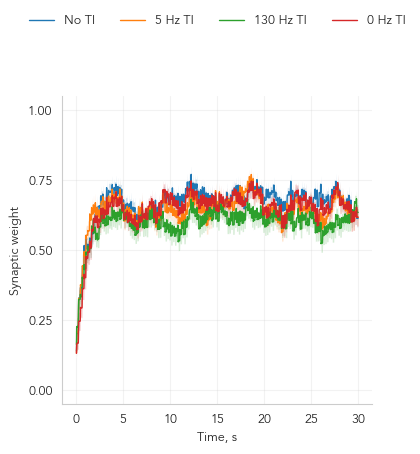

In [87]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (4, 4))
ax = axs

plot_average_synweight(
    ax = ax
)

ax.legend(loc = "upper center", ncol = 4, frameon = False, bbox_to_anchor = (0.5, 1.3))
plt.show()